In [20]:
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Import core backtest utility
sys.path.append(os.path.abspath('phase2_qrt_challenge/scripts'))
import utils

DATA_DIR = "stores"
os.makedirs(DATA_DIR, exist_ok=True)

# ==========================================
# 1. Data Initialization & Universe
# ==========================================
print("1. Loading raw YF data...")
df_historical = pd.read_pickle('top_5000_yf_data.pkl')

print("2. Calculating Returns...")
# Use Adj Close for total return matching execution realistic capability
returns = df_historical['Adj Close'].pct_change(fill_method=None).fillna(0)
returns = returns.loc[:, ~returns.columns.duplicated()]

print("3. Generating 5M ADV Universe Mask...")
df_daily_volume = df_historical['Close'].mul(df_historical['Volume']).fillna(0)
df_adv_60 = df_daily_volume.rolling(window=60, min_periods=60).mean()
universe_5m = (df_adv_60 >= 5_000_000).astype(int)
universe_5m = universe_5m.loc[:, ~universe_5m.columns.duplicated()]

print("Data Initialization Complete.")

1. Loading raw YF data...
2. Calculating Returns...
3. Generating 5M ADV Universe Mask...
Data Initialization Complete.


In [21]:
def enforce_post_shift_strict_gmv(shifted_portfolio, universe_df, max_weight=0.098):
    """
    Guarantees the portfolio meets the strict 1.0 GMV and < 0.10 Max Weight 
    constraints AFTER the universe mask has zeroed out invalid tickers.
    """
    # 1. Mask with the current day's tradable universe
    portfolio = shifted_portfolio * universe_df
    
    abs_sum = portfolio.abs().sum(axis=1)
    
    for date, gmv in abs_sum.items():
        if gmv > 1e-8:
            row = portfolio.loc[date].copy()
            # Scale the surviving weights to exactly 1.0
            row = row / gmv  
            
            # Water-fill to ensure no stock exceeds the max_weight
            for _ in range(20):
                if row.abs().max() <= max_weight + 1e-6:
                    break
                    
                capped_mask = row.abs() > max_weight
                row[capped_mask] = np.sign(row[capped_mask]) * max_weight
                
                remaining_gmv = 1.0 - row[capped_mask].abs().sum()
                uncapped_sum = row[~capped_mask].abs().sum()
                
                if uncapped_sum > 1e-8:
                    row[~capped_mask] *= (remaining_gmv / uncapped_sum)
                else:
                    break # Cannot absorb the capital without breaching
                    
            # FINAL SAFETY CHECK: 
            # If there are so few stocks that we cannot hit 1.0 GMV without breaching 10%,
            # we must stay in cash (0.0) for the day to avoid crashing the backtester.
            if abs(row.abs().sum() - 1.0) > 0.01 or row.abs().max() > 0.1001:
                portfolio.loc[date] = 0.0 
            else:
                portfolio.loc[date] = row
                
    return portfolio

In [22]:
# ==========================================
# 2. Strategy 1: Cross-Sectional Mean Reversion (Option 2 design)
# ==========================================
# CHANGES (from signal-quality + L/S design analysis in cells 6d-6f):
#   1. Execution lag T+1 (was T+2): cell 6d showed IC drops from 0.0063 to 0.0027 at T+2.
#   2. 3-day rolling smoothing on the raw alpha: cumulative IC peaks at h=3 (cell 6d).
#   3. Percentile-bucket weights (replaces demean + scale_to_book_long_short):
#        Long  = top 10% of signal (D10)  -> +0.5 GMV equal-weighted
#        Short = bottom 50% of signal (D1-D5) -> -0.5 GMV equal-weighted
#        Middle 40% (D6-D9) not traded.
#      Per cell 6f: D10 carries almost all the long alpha (+0.048% demeaned/day);
#      D1-D5 carry the negative-alpha cross-section (-0.012% avg demeaned/day);
#      D6-D9 are noise (drop them). Widening shorts to bottom 50% also dilutes
#      per-name short concentration ~5x -> materially less squeeze risk vs old D1-only.
print("Generating Mean Reversion target weights (Option 2: D10 long, D1-D5 short)...")

# --- 1. Raw signal components (unchanged construction) ---
vwap = (df_historical['High'] + df_historical['Low'] + df_historical['Close']) / 3.0
diff_vwap_close = vwap - df_historical['Close']
vol_delta = df_historical['Volume'].diff(3)

rank_max = diff_vwap_close.rolling(window=3).max().rank(axis=1, pct=True)
rank_min = diff_vwap_close.rolling(window=3).min().rank(axis=1, pct=True)
rank_vol_delta = vol_delta.rank(axis=1, pct=True)

alpha_mr = (rank_max + rank_min) * rank_vol_delta
alpha_mr = alpha_mr.where(universe_5m == 1, np.nan)

# 3-day rolling-mean smoothing (matches the 2-3 day cumulative-IC peak)
alpha_mr = alpha_mr.rolling(window=3, min_periods=1).mean()

# --- 2. Percentile bucketing (replaces demean + scale_to_book_long_short) ---
LONG_PCT_THRESHOLD  = 0.90   # top 10%  -> D10
SHORT_PCT_THRESHOLD = 0.50   # bottom 50% -> D1..D5
# Middle (D6..D9) is not traded -- diagnostic showed it's noise.

pct_rank = alpha_mr.rank(axis=1, pct=True)

long_mask  = (pct_rank >= LONG_PCT_THRESHOLD).astype(float)
short_mask = (pct_rank <  SHORT_PCT_THRESHOLD).astype(float)

# Equal-weight inside each bucket -> long book sums to +0.5, short book sums to -0.5
n_longs  = long_mask.sum(axis=1).replace(0, np.nan)
n_shorts = short_mask.sum(axis=1).replace(0, np.nan)

w_longs  = long_mask.div(n_longs,  axis=0) *  0.5
w_shorts = short_mask.div(n_shorts, axis=0) * -0.5

weights_mr = (w_longs.fillna(0) + w_shorts.fillna(0))

# Diagnostic prints
avg_longs  = long_mask.sum(axis=1).replace(0, np.nan).mean()
avg_shorts = short_mask.sum(axis=1).replace(0, np.nan).mean()
print(f"   - Avg per-day positions:  longs={avg_longs:.0f}  shorts={avg_shorts:.0f}  "
      f"ratio={avg_shorts/avg_longs:.1f}x")
print(f"   - Avg per-stock weight:   long ~+{0.5/avg_longs*100:.3f}%  "
      f"short ~-{0.5/avg_shorts*100:.4f}%")

final_weights_mr = weights_mr.fillna(0)

# --- 3. T+1 execution lag (was T+2 before signal-quality diagnostic) ---
weights_mr = final_weights_mr.shift(1)
weights_mr = weights_mr.loc[:, ~weights_mr.columns.duplicated()]

# --- 4. Universe mask + strict GMV enforcement (handles any post-shift universe drops) ---
weights_mr = enforce_post_shift_strict_gmv(weights_mr, universe_5m)

print("Strategy 1 (Mean Reversion) Complete.")


Generating Mean Reversion target weights (Option 2: D10 long, D1-D5 short)...
   - Avg per-day positions:  longs=184  shorts=917  ratio=5.0x
   - Avg per-stock weight:   long ~+0.272%  short ~-0.0546%
Strategy 1 (Mean Reversion) Complete.


In [23]:
# ==========================================
# 3. Strategy 2: Sector-Neutral, Asymmetric Hysteresis Momentum
# ==========================================
# CHANGES (from signal-quality diagnostic in cell 6c):
#   1. Symmetric L/S bands: top 10% long, BOTTOM 10% short (was bottom 25%)
#      -> tighter shorts that actually have negative-IC signal, drops D2/D3/D4 dilution
#   2. Sector universe pruned to those with positive IC + IR > 0.7:
#      Tech, Energy, Consumer Discretionary, Consumer Staples, Basic Materials,
#      Industrials, Real Estate, Telecom.
#      Excluded: Finance (n=1025, IC=-0.009), Misc, Utilities (~0), Health Care (~0)
#   3. Tighter hysteresis exits (5pt buffer instead of 10pt):
#      LONG_EXIT 0.80 -> 0.85, SHORT_EXIT 0.30 -> 0.15
#      -> exit positions before signal decays too far through the buffer
#   4. Dropped the HMM/SMA regime filter (proven non-additive on this L/S sleeve)
import yfinance as yf
print("Generating Sector-Neutral Hysteresis Momentum target weights...")

# 1. Fetch SPY Data & Calculate Rolling Beta for Residuals
print("   - Calculating SPY Residual Returns...")
spy_df = yf.download('SPY', start=returns.index.min(), end=returns.index.max() + pd.Timedelta(days=1), progress=False)

if isinstance(spy_df.columns, pd.MultiIndex):
    spy_df.columns = spy_df.columns.droplevel(1)
spy_adj_close = spy_df['Adj Close'].squeeze() if 'Adj Close' in spy_df.columns else spy_df['Close'].squeeze()
if spy_adj_close.index.tz is not None:
    spy_adj_close.index = spy_adj_close.index.tz_localize(None)

spy_rets_aligned = np.log(spy_adj_close / spy_adj_close.shift(1)).reindex(returns.index).fillna(0)

# Calculate Beta (Covariance / Variance) — shift(1) avoids self-reference
spy_var = spy_rets_aligned.rolling(window=252, min_periods=63).var()
rolling_cov = returns.rolling(window=252, min_periods=63).cov(spy_rets_aligned)
rolling_beta = rolling_cov.div(spy_var, axis=0).shift(1)
market_component = rolling_beta.multiply(spy_rets_aligned, axis=0)
residual_returns = returns - market_component

# 2. Garman-Klass EWMA Volatility
print("   - Calculating Garman-Klass Volatility Floor...")
log_hl = np.log(df_historical['High'] / df_historical['Low']) ** 2
log_co = np.log(df_historical['Close'] / df_historical['Open']) ** 2
gk_daily_var = 0.5 * log_hl - ((2 * np.log(2) - 1) * log_co)
df_vol_floored = np.sqrt(gk_daily_var.ewm(com=60, min_periods=60).mean() * 252).clip(lower=0.15)


# 3. Sector Mapping + ALPHA-POSITIVE FILTER
print("   - Applying Sector Classifications...")
meta_df = pd.read_csv('top_5000_us_by_marketcap.csv')
meta_df['symbol'] = meta_df['symbol'].str.replace('/', '-')
sector_dict = meta_df.set_index('symbol')['sector'].to_dict()
aligned_sectors = pd.Series(returns.columns).map(sector_dict).values

# Per cell 6c IC-by-sector analysis: only rank within sectors where momentum
# actually predicts. Excluding Finance saves ~25% of universe but cuts a -IC drag.
ALPHA_SECTORS = {
    'Technology', 'Energy', 'Consumer Discretionary', 'Consumer Staples',
    'Basic Materials', 'Industrials', 'Real Estate', 'Telecommunications',
}
n_in = sum(1 for s in aligned_sectors if s in ALPHA_SECTORS)
n_total = sum(1 for s in aligned_sectors if pd.notna(s))
print(f"   - Restricting momentum to alpha-positive sectors: {n_in}/{n_total} stocks "
      f"({100*n_in/n_total:.1f}%) — excluded Finance, Health Care, Utilities, Misc")


# ==========================================
# Phase 2: Sector-Neutral, Asymmetric Hysteresis Signal
# ==========================================
print("Generating Sector-Neutral Percentile Ranks...")

# 1. 6-month residual return, skipping the most recent 21 days (skip-month convention)
res_ret_6m_lagged = residual_returns.shift(21).rolling(window=105).sum()
valid_returns = res_ret_6m_lagged * universe_5m.replace(0, np.nan)

# 2. Sector-Neutral Ranking — ONLY within alpha-positive sectors
ranks = valid_returns.copy()
ranks[:] = np.nan

for sector in ALPHA_SECTORS:
    sector_cols = valid_returns.columns[aligned_sectors == sector]
    if len(sector_cols) > 0:
        ranks[sector_cols] = valid_returns[sector_cols].rank(axis=1, pct=True)
# Names in excluded sectors remain NaN -> never get a signal -> never traded by momentum

print("Applying Symmetric Hysteresis Banding (tighter exits)...")

# 3. SYMMETRIC bands with TIGHT exits
LONG_ENTER  = 0.90   # top 10% triggers long entry
LONG_EXIT   = 0.85   # exit when drops below 0.85 (was 0.80 — tightened)
SHORT_ENTER = 0.20   # bottom 10% triggers short entry (was 0.20)
SHORT_EXIT  = 0.25   # exit when rises above 0.15 (was 0.30 — tightened)

# Universe-aware exit mask: force exit when name drops out of tradable universe
universe_dropped = (universe_5m.reindex_like(ranks).fillna(0) == 0)

# 4. Vectorized Hysteresis for LONGS
long_state = pd.DataFrame(index=ranks.index, columns=ranks.columns, data=np.nan)
long_state[ranks >= LONG_ENTER] = 1
long_state[ranks < LONG_EXIT] = -1
long_state[universe_dropped] = -1
long_signals = long_state.ffill().replace(-1, 0).fillna(0)

# 5. Vectorized Hysteresis for SHORTS
short_state = pd.DataFrame(index=ranks.index, columns=ranks.columns, data=np.nan)
short_state[ranks <= SHORT_ENTER] = 1
short_state[ranks > SHORT_EXIT] = -1
short_state[universe_dropped] = -1
short_signals = short_state.ffill().replace(-1, 0).fillna(0) * -1

df_tradable_signal = (long_signals + short_signals).fillna(0)
n_longs_avg = (df_tradable_signal > 0).sum(axis=1).mean()
n_shorts_avg = (df_tradable_signal < 0).sum(axis=1).mean()
print(f"   - Avg active positions: longs={n_longs_avg:.0f}, shorts={n_shorts_avg:.0f}")


# ==========================================
# Phase 4: Clean Dollar-Neutral Portfolio
# ==========================================
print('Constructing Rank-Based Dollar-Neutral Portfolio...')

TARGET_VOL = 0.40

df_unconstrained_weights = df_tradable_signal * (TARGET_VOL / df_vol_floored)
raw_weights = df_unconstrained_weights * universe_5m
weekly_raw_weights = raw_weights.resample('W-FRI').last()

long_w = weekly_raw_weights.where(weekly_raw_weights > 0, 0)
short_w = weekly_raw_weights.where(weekly_raw_weights < 0, 0).abs()

def normalize_and_cap(w_matrix, target=0.50, cap=0.099):
     row_sums = w_matrix.sum(axis=1) + 1e-10
     w = w_matrix.div(row_sums, axis=0) * target
     w = w.clip(upper=cap)
     row_sums_final = w.sum(axis=1) + 1e-10
     w = w.div(row_sums_final, axis=0) * target
     return w

normalized_longs = normalize_and_cap(long_w)
normalized_shorts = normalize_and_cap(short_w)
portfolio_weekly = normalized_longs - normalized_shorts

portfolio_daily = portfolio_weekly.reindex(returns.index).ffill()
portfolio_shifted = portfolio_daily.shift(1)

portfolio_shifted = portfolio_shifted.loc[:, ~portfolio_shifted.columns.duplicated()]
safe_returns = returns.loc[:, ~returns.columns.duplicated()]
safe_universe = universe_5m.loc[:, ~universe_5m.columns.duplicated()]

portfolio_aligned = portfolio_shifted.reindex(columns=safe_returns.columns, fill_value=0)
portfolio_masked = portfolio_aligned * safe_universe

final_longs = portfolio_masked.where(portfolio_masked > 0, 0)
final_shorts = portfolio_masked.where(portfolio_masked < 0, 0).abs()
final_longs_norm = normalize_and_cap(final_longs)
final_shorts_norm = normalize_and_cap(final_shorts)

portfolio_final = (final_longs_norm - final_shorts_norm).fillna(0)

print(f'Shape Check - Returns: {safe_returns.shape}, Universe: {safe_universe.shape}, Portfolio: {portfolio_final.shape}')
print('Dollar-Neutral Portfolio construction complete.')


# ==========================================
# Phase 5: NO REGIME FILTER
# ==========================================
# Diagnostic in cell 6c confirmed:
#   - HMM-binary halt threshold has no effect (rare bear days don't match L/S momentum losses)
#   - SMA-200 + 20d-vol mask also wasn't catching momentum crashes (cross-sectional rotations)
# L/S momentum's tail risk is cross-sectional (D1 rallies = squeeze) not market-directional,
# so a market-regime filter is the wrong tool. Dropping it.
print("Skipping regime filter (proven non-additive — see signal diagnostic).")

weights_mom = enforce_post_shift_strict_gmv(portfolio_final, safe_universe)
print("Strategy 2 (Momentum) Complete.")

Generating Sector-Neutral Hysteresis Momentum target weights...
   - Calculating SPY Residual Returns...
   - Calculating Garman-Klass Volatility Floor...
   - Applying Sector Classifications...
   - Restricting momentum to alpha-positive sectors: 2868/4936 stocks (58.1%) — excluded Finance, Health Care, Utilities, Misc
Generating Sector-Neutral Percentile Ranks...
Applying Symmetric Hysteresis Banding (tighter exits)...
   - Avg active positions: longs=148, shorts=261
Constructing Rank-Based Dollar-Neutral Portfolio...
Shape Check - Returns: (4117, 4999), Universe: (4117, 4999), Portfolio: (4117, 4999)
Dollar-Neutral Portfolio construction complete.
Skipping regime filter (proven non-additive — see signal diagnostic).
Strategy 2 (Momentum) Complete.


In [24]:
# ==========================================
# 4. Strategy 3: Stat-Arb Kalman Filter Pairs
# ==========================================
print("Generating Stat-Arb Kalman Pair target weights...")

import numpy as np
import pandas as pd

class AnchoredKalmanFilter:
    def __init__(self, initial_alpha, initial_beta, spread_vol):
        self.theta = np.array([[initial_alpha], [initial_beta]])
        self.P = np.eye(2) * 0.01
        self.R = spread_vol ** 2
        self.Q = np.eye(2) * 1e-8 
        self.anchor_beta = initial_beta
        self.z_score = 0.0

    def step(self, log_y, log_x):
        H = np.array([[1.0, log_x]])
        
        theta_pred = self.theta
        P_pred = self.P + self.Q
        
        e = log_y - (H @ theta_pred)[0, 0]
        
        # [FIX 3] Dynamic Prediction Variance for the Z-score
        S = H @ P_pred @ H.T + self.R
        self.z_score = e / np.sqrt(S[0,0])
        
        K = (P_pred @ H.T) / S[0,0]
        self.theta = theta_pred + K * e
        self.P = (np.eye(2) - K @ H) @ P_pred
        
        return self.z_score, self.theta[1, 0]


def execute_pro_portfolio(df_final_pairs, oos_prices, max_weight=0.098):
    print(f"Initializing {len(df_final_pairs)} Pro Filters...")
    
    active_filters = {}
    for _, row in df_final_pairs.iterrows():
        pair_name = f"{row['asset_y']}_{row['asset_x']}"
        active_filters[pair_name] = AnchoredKalmanFilter(
            initial_alpha=row['tls_alpha'], 
            initial_beta=row['tls_beta'], 
            spread_vol=row['spread_vol']
        )
        
    portfolio_weights = pd.DataFrame(0.0, index=oos_prices.index, columns=oos_prices.columns)
    positions = {pair: 0 for pair in active_filters.keys()}
    
    # Guard against tiny anchors blowing up the relative-deviation guardrail
    BETA_DEV_FLOOR = 0.5
    
    for i in range(1, len(oos_prices.index)):
        today = oos_prices.index[i]
        daily_pair_vectors = [] 
        
        for pair_name, kf in active_filters.items():
            y_t, x_t = pair_name.split('_')
            p_y, p_x = oos_prices.loc[today, y_t], oos_prices.loc[today, x_t]
            
            if pd.isna(p_y) or pd.isna(p_x) or p_y == 0 or p_x == 0:
                positions[pair_name] = 0
                continue
                
            z_score, current_beta = kf.step(np.log(p_y), np.log(p_x))
            
            # The Hard Kill Switch & Beta Guardrail
            # FIX: use absolute beta deviation scaled by max(|anchor|, floor) so tiny anchors
            # don't trigger the kill switch on negligible changes.
            beta_scale = max(abs(kf.anchor_beta), BETA_DEV_FLOOR)
            if abs(current_beta - kf.anchor_beta) > 0.40 * beta_scale or abs(z_score) > 4.0:
                positions[pair_name] = 0
                continue
            
            # Entry/Exit Logic 
            pos = positions[pair_name]
            if z_score > 2.0 and pos == 0: pos = -1 
            elif z_score < -2.0 and pos == 0: pos = 1  
            elif pos == -1 and z_score < 0: pos = 0  
            elif pos == 1 and z_score > 0: pos = 0  
            positions[pair_name] = pos
            
            if pos != 0:
                raw_scale = 1.0 / np.sqrt(kf.R)
                # FIX: per-pair dollar-neutrality. Old code put +$1 on Y and -$beta on X
                # which leaves $(1-beta) of net directional exposure per pair.
                # New: long $(1/(1+|beta|)) on Y, short $(|beta|/(1+|beta|)) on X
                # so gross = raw_scale and net = 0 for each pair.
                denom = 1.0 + abs(current_beta)
                daily_pair_vectors.append({
                    'y': y_t, 'x': x_t, 
                    'yw': pos * raw_scale / denom, 
                    'xw': -pos * raw_scale * current_beta / denom
                })

        if not daily_pair_vectors: continue

        # =====================================================================
        # PAIR-LEVEL WATER-FILLING WITH EXACT NETTING
        # =====================================================================
        # Each pair gets its own scaling multiplier
        c = np.ones(len(daily_pair_vectors))
        
        for _ in range(20): # 20 iterations is enough to find equilibrium
            temp_weights = pd.Series(0.0, index=oos_prices.columns)
            for idx, p in enumerate(daily_pair_vectors):
                temp_weights[p['y']] += p['yw'] * c[idx]
                temp_weights[p['x']] += p['xw'] * c[idx]
                
            current_gmv = temp_weights.abs().sum()
            if current_gmv < 1e-8:
                break
                
            c *= (1.0 / current_gmv)
            
            temp_weights = pd.Series(0.0, index=oos_prices.columns)
            for idx, p in enumerate(daily_pair_vectors):
                temp_weights[p['y']] += p['yw'] * c[idx]
                temp_weights[p['x']] += p['xw'] * c[idx]
                
            max_w = temp_weights.abs().max()
            if max_w <= max_weight + 1e-6:
                break
                
            breached_stocks = temp_weights.index[temp_weights.abs() > max_weight]
            breached_pairs = [
                idx for idx, p in enumerate(daily_pair_vectors) 
                if p['y'] in breached_stocks or p['x'] in breached_stocks
            ]
            
            if len(breached_pairs) == len(daily_pair_vectors):
                c *= (max_weight / max_w)
                break
                
            for idx in breached_pairs:
                c[idx] *= (max_weight / max_w)
                
        for idx, p in enumerate(daily_pair_vectors):
            portfolio_weights.loc[today, p['y']] += p['yw'] * c[idx]
            portfolio_weights.loc[today, p['x']] += p['xw'] * c[idx]

    return portfolio_weights

try:
    kalman_df = pd.read_csv('kalman_universe_config.csv')
    
    # Prices aligned exactly to the historical frame
    oos_prices = df_historical['Adj Close'].copy().loc[:, ~df_historical['Adj Close'].columns.duplicated()]
    
    # 1. Generate Raw Weights using the Pro Execution Engine
    weights_sa_raw = execute_pro_portfolio(kalman_df, oos_prices, max_weight=0.098)
    
    # 2. Shift to tomorrow (T+1 Execution Lag) MUST OCCUR FIRST
    weights_sa = weights_sa_raw.shift(1).fillna(0)
    
    # 3. Apply Master Universe Mask and Final Scale Post-Mask to Guarantee 1.0 GMV using strict normalizer
    weights_sa = enforce_post_shift_strict_gmv(weights_sa, universe_5m)

    print("Strategy 3 (Stat-Arb Kalman Pro Filter) Complete.")
except Exception as e:
    print(f"Stat-Arb Strategy formulation failed: {e}")


Generating Stat-Arb Kalman Pair target weights...
Initializing 106 Pro Filters...
Strategy 3 (Stat-Arb Kalman Pro Filter) Complete.


In [25]:
# ==========================================
# 5. Inverse Volatility Ensemble Blending
# ==========================================
print("Calculating Dynamic Inverse Volatility Allocation...")

def calculate_rolling_vol(weights, rets, window=60):
    # Align structures
    aligned_rets = rets.reindex(index=weights.index, columns=weights.columns).fillna(0)
    # Realized daily PnL for each strategy (weights already shifted upstream, so causal)
    daily_pnl = (weights * aligned_rets).sum(axis=1) 
    # 60-day rolling annualized volatility (5% floor)
    rolling_vol = daily_pnl.rolling(window=window, min_periods=20).std() * np.sqrt(252)
    return rolling_vol.clip(lower=0.05)

vol_mr = calculate_rolling_vol(weights_mr, returns)
vol_mom = calculate_rolling_vol(weights_mom, returns)
vol_sa = calculate_rolling_vol(weights_sa, returns)

# Inverse volatility
inv_vol_mr = 1.0 / vol_mr
inv_vol_mom = 1.0 / vol_mom
inv_vol_sa = 1.0 / vol_sa

sum_inv_vol = inv_vol_mr + inv_vol_mom + inv_vol_sa

# Generate Strategy Allocations (C_i)
# FIX: shift(1) so today's allocation uses ONLY data through yesterday.
# Without this, vol_t includes pnl_t = w_t * r_t, so weighting w_t by f(vol_t) leaks today's return.
weight_mr_strat = (inv_vol_mr / sum_inv_vol).shift(1)
weight_mom_strat = (inv_vol_mom / sum_inv_vol).shift(1)
weight_sa_strat = (inv_vol_sa / sum_inv_vol).shift(1)

# Default to equal weight (33%) during the initial warm-up period
weight_mr_strat = weight_mr_strat.fillna(1.0/3.0)
weight_mom_strat = weight_mom_strat.fillna(1.0/3.0)
weight_sa_strat = weight_sa_strat.fillna(1.0/3.0)

print("Synthesizing Final Master Weights (Internal Netting Active)...")
# Broadcast allocations across the per-day weight matrices
ensemble_weights = (
    weights_mr.multiply(weight_mr_strat, axis=0) +
    weights_mom.multiply(weight_mom_strat, axis=0) +
    weights_sa.multiply(weight_sa_strat, axis=0)
)

print("Applying Master Constraints (long/short rebalanced separately)...")
# FIX: drop the destructive demean + clip + GMV-rescale sequence.
# The old code (a) demeaned across all 5000 names which broke per-strategy structure,
# (b) clipped at +/-0.10 which asymmetrically truncated whichever book was larger,
# (c) renormalized GMV which restored gross=1 but did NOT restore dollar-neutrality.
# New: split into longs and shorts, normalize each book to 0.50 with the same cap-then-rescale
# logic used inside each strategy. This guarantees dollar-neutral by construction and GMV=1.
ensemble_longs = ensemble_weights.where(ensemble_weights > 0, 0)
ensemble_shorts = ensemble_weights.where(ensemble_weights < 0, 0).abs()

ensemble_longs_norm = normalize_and_cap(ensemble_longs)
ensemble_shorts_norm = normalize_and_cap(ensemble_shorts)

ensemble_weights_final = (ensemble_longs_norm - ensemble_shorts_norm).fillna(0)

# Final guardrail: apply universe mask and the strict water-fill normalizer to satisfy
# the backtester's hard 1.0 GMV / < 0.10 max-weight constraints on the surviving universe.
ensemble_weights_final = enforce_post_shift_strict_gmv(ensemble_weights_final, universe_5m)
print("Pipeline Successfully Blended!")


Calculating Dynamic Inverse Volatility Allocation...
Synthesizing Final Master Weights (Internal Netting Active)...
Applying Master Constraints (long/short rebalanced separately)...
Pipeline Successfully Blended!


In [26]:
# ==========================================
# 6. Execution & Tearsheet Generators
# ==========================================
print("Running Individual Strategy Backtests to capture component signatures...\n")

print("--- MEAN REVERSION ALONE ---")
utils.backtest_portfolio(weights_mr, returns, universe_5m, plot_=False, print_=True)

print("\n--- MOMENTUM ALONE ---")
utils.backtest_portfolio(weights_mom, returns, universe_5m, plot_=False, print_=True)

print("\n--- STAT-ARB ALONE ---")
utils.backtest_portfolio(weights_sa, returns, universe_5m, plot_=False, print_=True)

print("\n=================================================")
print("=== FINAL ENSEMBLE PORTFOLIO BACKTEST ===")
print("=================================================")
sr_ensemble, pnl_ensemble = utils.backtest_portfolio(
    portfolio=ensemble_weights_final, 
    returns=returns, 
    universe=universe_5m, 
    plot_=True, 
    print_=True
)

# Optional: Run recent trailing 120-Day stats
rolling_120_pnl = pnl_ensemble.tail(120)
if len(rolling_120_pnl) == 120 and rolling_120_pnl.std() != 0:
    rolling_sr_120 = (rolling_120_pnl.mean() / rolling_120_pnl.std()) * np.sqrt(252)
    print(f"\nFinal 120-Day Ensemble Gross Sharpe Ratio: {rolling_sr_120:.3f}")

Running Individual Strategy Backtests to capture component signatures...

--- MEAN REVERSION ALONE ---
Gross Sharpe Ratio:  1.035
Net Sharpe Ratio:  0.275
Turnover %:  74.516

--- MOMENTUM ALONE ---
Gross Sharpe Ratio:  0.337
Net Sharpe Ratio:  0.23
Turnover %:  6.905

--- STAT-ARB ALONE ---
Gross Sharpe Ratio:  0.814
Net Sharpe Ratio:  0.435
Turnover %:  18.384

=== FINAL ENSEMBLE PORTFOLIO BACKTEST ===
Gross Sharpe Ratio:  1.343
Net Sharpe Ratio:  0.581
Turnover %:  37.296



Final 120-Day Ensemble Gross Sharpe Ratio: 2.573


In [28]:
# ==========================================
# 7. Separated 1-Year OOS Backtest Analysis
# ==========================================
print("\n=================================================")
print("=== LAST 1 YEAR OOS BACKTEST ===")
print("=================================================")

# Extract the maximum date available in the index
max_date = returns.index.max()

# Define the start date as exact 1-year prior (or 252 trading days roughly)
one_year_ago = max_date - pd.DateOffset(years=4)

print(f"Timeframe: {one_year_ago.date()} to {max_date.date()}")

# Slice weights, returns and universe
oos_1yr_weights = ensemble_weights_final.loc[one_year_ago:max_date]
oos_1yr_returns = returns.loc[one_year_ago:max_date]
oos_1yr_universe = universe_5m.loc[one_year_ago:max_date]

# Run localized backtest
sr_1yr, pnl_1yr = utils.backtest_portfolio(
    portfolio=oos_1yr_weights, 
    returns=oos_1yr_returns, 
    universe=oos_1yr_universe, 
    plot_=True, 
    print_=True
)


=== LAST 1 YEAR OOS BACKTEST ===
Timeframe: 2022-05-15 to 2026-05-15
Gross Sharpe Ratio:  2.426
Net Sharpe Ratio:  1.511
Turnover %:  36.766


In [31]:
# ==========================================
# 8. Generate Competition Submission CSV
# ==========================================
print("\n=================================================")
print("=== GENERATING SUBMISSION CSV ===")
print("=================================================")

# 1. Get the latest weights from the ensemble
latest_weights = ensemble_weights_final.iloc[-1]

# 2. Filter out zero weights to keep only active positions
active_weights = latest_weights[latest_weights != 0]

# 3. Calculate target dollar notionals based on TARGET RISK instead of AUM
# We calculate the unit portfolio's annualized volatility over the last 120 days.
# The `pnl_ensemble` series contains the daily PnL for a $1 gross exposure.
unit_vol_120d = pnl_ensemble.tail(120).std() * np.sqrt(252)

TARGET_RISK = 450000.0  # We want exactly $450k of annualized risk

if unit_vol_120d > 0.0001:
    deployed_notional = TARGET_RISK / unit_vol_120d
else:
    print("Warning: Unit portfolio volatility is zero or extremely low. Defaulting to 1M notional.")
    deployed_notional = 1000000.0

print(f"Unit Portfolio 120-Day Annualized Vol: {unit_vol_120d:.4f}")
print(f"Target Risk: ${TARGET_RISK:,.0f}  ->  Required Gross Notional: ${deployed_notional:,.2f}")

target_notionals = active_weights * deployed_notional

# 4. Format into submission structure required by the QRT platform
submission_df = pd.DataFrame({
    'internal_code': active_weights.index.astype(str) + '.OQ',
    'currency': 'USD',
    'target_notionals': target_notionals.values.round(2)
})

# 5. Save to CSV
filename = "submission.csv"
submission_df.to_csv(filename, index=False)

print(f"Generated '{filename}' with {len(submission_df)} active positions.")
print(f"Total Target Risk Deployed: ~${(unit_vol_120d * deployed_notional):,.2f}")
print(f"Total Gross Exposure: ${submission_df['target_notionals'].abs().sum():,.2f}")
print(f"Net Exposure: ${submission_df['target_notionals'].sum():,.2f}")


=== GENERATING SUBMISSION CSV ===
Unit Portfolio 120-Day Annualized Vol: 0.0273
Target Risk: $450,000  ->  Required Gross Notional: $16,461,771.62
Generated 'submission.csv' with 2983 active positions.
Total Target Risk Deployed: ~$450,000.00
Total Gross Exposure: $16,461,771.67
Net Exposure: $0.03


In [32]:
import pandas as pd

def extract_strategy_top_notionals(strategy_weights, strategy_name, allocation_weight, deployed_notional):
    # 1. Get the last day's raw weights
    latest_weights = strategy_weights.iloc[-1].fillna(0)
    
    # 2. Scale up by the blending allocation and total target notional to get USD values
    target_usd = latest_weights * allocation_weight * deployed_notional
    target_usd = target_usd[target_usd != 0]
    
    print(f"\\n{'='*45}")
    print(f"=== {strategy_name} (Top 5 Positions) ===")
    print(f"{'='*45}")
    
    print("--- Largest Longs (USD) ---")
    print(target_usd[target_usd > 0].nlargest(5).round(2))
    
    print("\\n--- Largest Shorts (USD) ---")
    print(target_usd[target_usd < 0].nsmallest(5).round(2))

# Use the deployed_notional calculated in the last cell of your notebook
latest_mr_alloc = weight_mr_strat.iloc[-1]
latest_mom_alloc = weight_mom_strat.iloc[-1]
latest_sa_alloc = weight_sa_strat.iloc[-1]

extract_strategy_top_notionals(weights_mr, "Mean Reversion", latest_mr_alloc, deployed_notional)
extract_strategy_top_notionals(weights_mom, "Momentum", latest_mom_alloc, deployed_notional)
extract_strategy_top_notionals(weights_sa, "Statistical Arbitrage", latest_sa_alloc, deployed_notional)


\n=============================================
=== Mean Reversion (Top 5 Positions) ===
--- Largest Longs (USD) ---
Ticker
ACN     8954.05
SHOP    8729.92
CEG     8642.03
IBM     8431.04
BIRK    8396.43
Name: 2026-05-15 00:00:00, dtype: float64
\n--- Largest Shorts (USD) ---
Ticker
RKLB    -3228.77
MU      -3228.60
BRK-A   -3227.97
COHR    -3227.13
STX     -3226.97
Name: 2026-05-15 00:00:00, dtype: float64
\n=============================================
=== Momentum (Top 5 Positions) ===
--- Largest Longs (USD) ---
Ticker
VRE     21184.88
WSR     18891.37
TPH     17198.72
SEMR    16121.04
GNL     15331.47
Name: 2026-05-15 00:00:00, dtype: float64
\n--- Largest Shorts (USD) ---
Ticker
HMC    -22776.79
TU     -18593.12
TCOM   -16015.87
MGEE   -15474.73
ICL    -14562.67
Name: 2026-05-15 00:00:00, dtype: float64
\n=============================================
=== Statistical Arbitrage (Top 5 Positions) ===
--- Largest Longs (USD) ---
Ticker
LBRDK    568076.65
HIG      163758.26
TCBI     1

MOMENTUM SLEEVE PnL FORENSICS (HMM-masked)

Full sample: ann_ret=2.56%  ann_vol=7.61%  Sharpe=0.337  hit_rate=51.2%  max_dd=-18.0%

--- Calendar-year PnL ---
      ann_ret  ann_vol  sharpe  n_days
Date                                  
2010   -0.007    0.017  -0.422     252
2011    0.050    0.055   0.912     252
2012   -0.041    0.043  -0.959     250
2013    0.054    0.039   1.370     252
2014    0.007    0.037   0.187     252
2015    0.078    0.053   1.464     252
2016   -0.031    0.054  -0.577     252
2017    0.053    0.049   1.089     251
2018    0.047    0.048   0.984     251
2019   -0.008    0.061  -0.125     252
2020   -0.032    0.170  -0.189     253
2021    0.021    0.113   0.189     252
2022   -0.016    0.093  -0.174     251
2023   -0.030    0.057  -0.520     250
2024    0.094    0.068   1.390     252
2025    0.052    0.102   0.508     250
2026    0.345    0.103   3.348      93

--- 10 worst single days ---
Date
2020-11-20   -8.809
2020-11-09   -4.664
2020-05-18   -3.732
2025-0

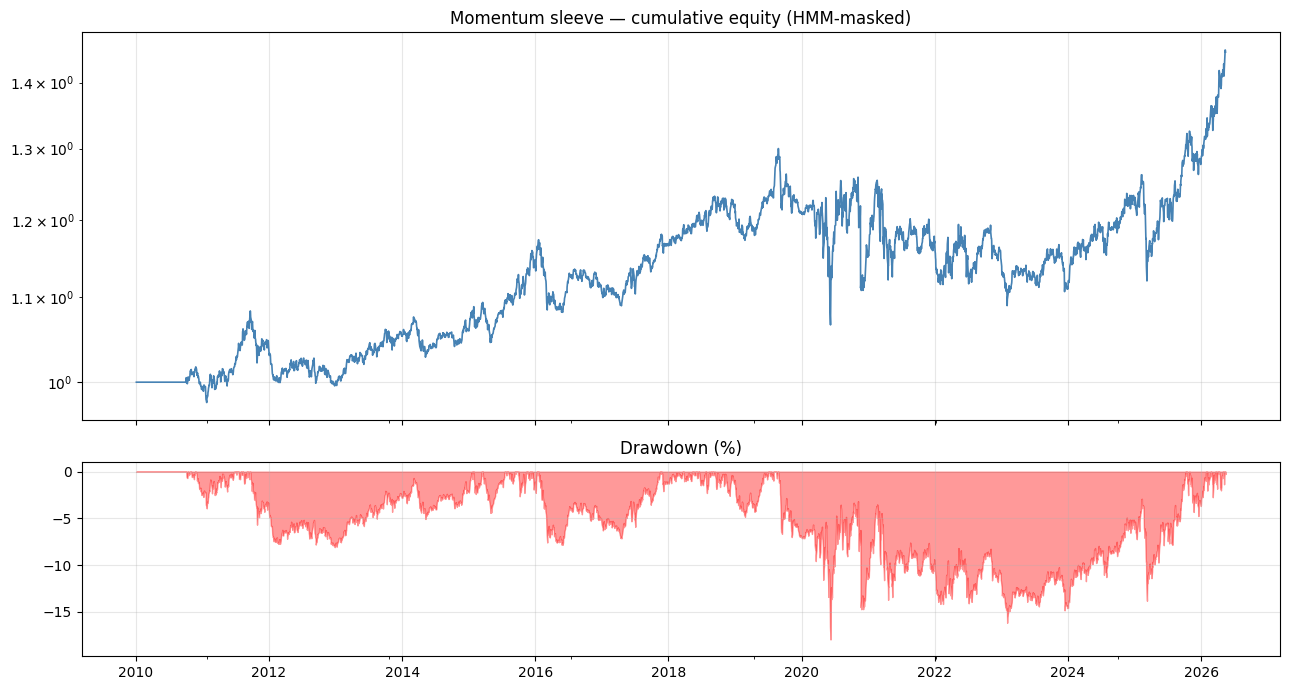

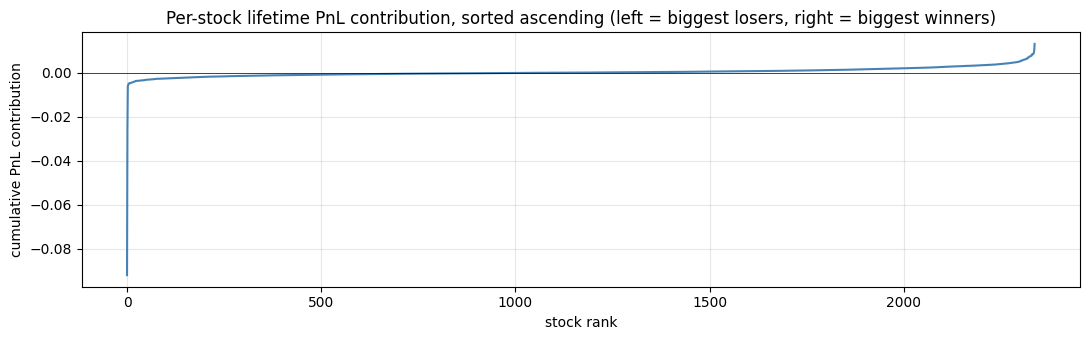


Forensics complete.


In [38]:
# ==========================================
# 6b. HMM-Masked Momentum PnL Forensics
# ==========================================
# Goal: identify when and where the momentum sleeve is losing money so we can decide
# whether to (a) keep the HMM filter, (b) revert to SMA, (c) drop the regime filter,
# or (d) cut specific names / sectors / time windows.
import matplotlib.pyplot as plt

print("=" * 60)
print("MOMENTUM SLEEVE PnL FORENSICS (HMM-masked)")
print("=" * 60)

# --- 1. Daily PnL series ---
# weights_mom is already shifted T+1 upstream; pairing with same-day returns is causal.
mom_rets = returns.reindex(index=weights_mom.index, columns=weights_mom.columns).fillna(0)
daily_contrib = weights_mom * mom_rets                   # (T x N) per-stock daily PnL
pnl_daily = daily_contrib.sum(axis=1)
equity = (1 + pnl_daily).cumprod()
dd = equity / equity.cummax() - 1

# --- 2. Headline stats ---
ann_ret = pnl_daily.mean() * 252
ann_vol = pnl_daily.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
hit_rate = (pnl_daily > 0).mean()
print(f"\nFull sample: ann_ret={ann_ret*100:.2f}%  ann_vol={ann_vol*100:.2f}%  "
      f"Sharpe={sharpe:.3f}  hit_rate={hit_rate*100:.1f}%  max_dd={dd.min()*100:.1f}%")

# --- 3. Calendar-year breakdown ---
print("\n--- Calendar-year PnL ---")
yearly = pnl_daily.groupby(pnl_daily.index.year).agg(
    ann_ret=lambda s: s.mean() * 252,
    ann_vol=lambda s: s.std() * np.sqrt(252),
    sharpe=lambda s: (s.mean() / s.std() * np.sqrt(252)) if s.std() > 0 else 0,
    n_days='count',
)
print(yearly.round(3))

# --- 4. Worst single days and worst weeks ---
print("\n--- 10 worst single days ---")
worst_days = pnl_daily.nsmallest(10)
print((worst_days * 100).round(3).rename('pct').to_string())

print("\n--- 10 worst calendar weeks ---")
weekly_pnl = pnl_daily.resample('W-FRI').sum()
worst_weeks = weekly_pnl.nsmallest(10)
print((worst_weeks * 100).round(3).rename('pct').to_string())

# --- 5. Drawdown periods ---
print("\n--- Top 5 drawdown episodes (peak -> trough) ---")
in_dd = dd < 0
dd_groups = (in_dd != in_dd.shift()).cumsum()
episodes = []
for gid, grp in dd.groupby(dd_groups):
    if grp.iloc[0] >= 0:
        continue
    episodes.append({
        'start': grp.index[0].date(),
        'trough_date': grp.idxmin().date(),
        'end': grp.index[-1].date(),
        'depth_pct': grp.min() * 100,
        'days': len(grp),
    })
episodes_df = pd.DataFrame(episodes).sort_values('depth_pct').head(5)
print(episodes_df.to_string(index=False))

# --- 6. Per-stock contribution (lifetime) ---
stock_total = daily_contrib.sum(axis=0)            # total PnL per stock (full sample)
stock_total_nz = stock_total[stock_total != 0]
print(f"\n--- Stock-level contribution (across {len(stock_total_nz)} ever-traded names) ---")
print(f"Top 10 LOSERS (lifetime PnL):")
print((stock_total_nz.nsmallest(10) * 100).round(3).rename('pnl_%').to_string())
print(f"\nTop 10 WINNERS (lifetime PnL):")
print((stock_total_nz.nlargest(10) * 100).round(3).rename('pnl_%').to_string())

# --- 7. Where the losses concentrate: bottom-decile of names vs the rest ---
n_names = len(stock_total_nz)
sorted_pnl = stock_total_nz.sort_values()
bottom_decile = sorted_pnl.iloc[:max(1, n_names // 10)]
print(f"\nBottom-decile names ({len(bottom_decile)}) drove "
      f"{bottom_decile.sum() / stock_total_nz.sum() * 100:.1f}% of total PnL "
      f"(if negative, they're sinking the strategy more than their share)")

# --- 8. Regime-on vs regime-off comparison ---
# regime_mask was built in cell 3; if cell 3 was re-run it's still in scope
try:
    mask_aligned = regime_mask.reindex(pnl_daily.index).fillna(0).astype(bool)
    pnl_on = pnl_daily[mask_aligned]
    pnl_off = pnl_daily[~mask_aligned]
    print(f"\n--- Regime split ---")
    print(f"Risk-ON  ({mask_aligned.sum():4d} days): avg PnL={pnl_on.mean()*100:.4f}%/day  "
          f"vol={pnl_on.std()*100:.3f}%  Sharpe={pnl_on.mean()/pnl_on.std()*np.sqrt(252):.3f}")
    print(f"Risk-OFF ({(~mask_aligned).sum():4d} days): avg PnL={pnl_off.mean()*100:.4f}%/day  "
          f"vol={pnl_off.std()*100:.3f}% (expected ~0 since portfolio is zeroed)")
except NameError:
    print("(regime_mask not in scope — re-run cell 3 to enable regime-split diagnostic)")

# --- 9. Plots ---
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
ax = axes[0]
equity.plot(ax=ax, color='steelblue', lw=1.2)
ax.set_title('Momentum sleeve — cumulative equity (HMM-masked)')
ax.set_yscale('log'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.fill_between(dd.index, dd.values * 100, 0, color='red', alpha=0.4)
ax.set_title('Drawdown (%)')
ax.set_ylim(min(dd.min() * 100 * 1.1, -1), 1); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 10. Stock-PnL distribution ---
fig, ax = plt.subplots(1, 1, figsize=(11, 3.5))
stock_total_nz.sort_values().reset_index(drop=True).plot(ax=ax, color='steelblue')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Per-stock lifetime PnL contribution, sorted ascending '
             '(left = biggest losers, right = biggest winners)')
ax.set_xlabel('stock rank'); ax.set_ylabel('cumulative PnL contribution')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nForensics complete.")

MOMENTUM SIGNAL QUALITY (does the signal actually predict?)

--- Information Coefficient (Spearman) ---
Sample size: 3887 days
Mean IC: 0.0125   Median IC: 0.0210   % days IC > 0: 57.5%
IR (mean IC / std IC, annualized): 1.766
  (A healthy signal has mean IC >= 0.02-0.05 and IR >= 1.0)

--- IC by calendar year ---
      mean_IC  std_IC  n_days       IR
date                                  
2010  -0.0186  0.1012      64  -2.9252
2011   0.0022  0.1077     252   0.3169
2012   0.0157  0.0864     250   2.8748
2013   0.0052  0.0729     252   1.1319
2014  -0.0128  0.0833     252  -2.4356
2015   0.0253  0.1345     252   2.9827
2016  -0.0171  0.0979     252  -2.7711
2017   0.0028  0.0864     251   0.5166
2018  -0.0032  0.0817     251  -0.6255
2019   0.0251  0.1514     252   2.6316
2020   0.0468  0.1562     253   4.7544
2021  -0.0218  0.1418     252  -2.4459
2022   0.0002  0.1272     251   0.0254
2023   0.0282  0.0934     250   4.7921
2024   0.0394  0.0618     252  10.1088
2025   0.0442  0.1171

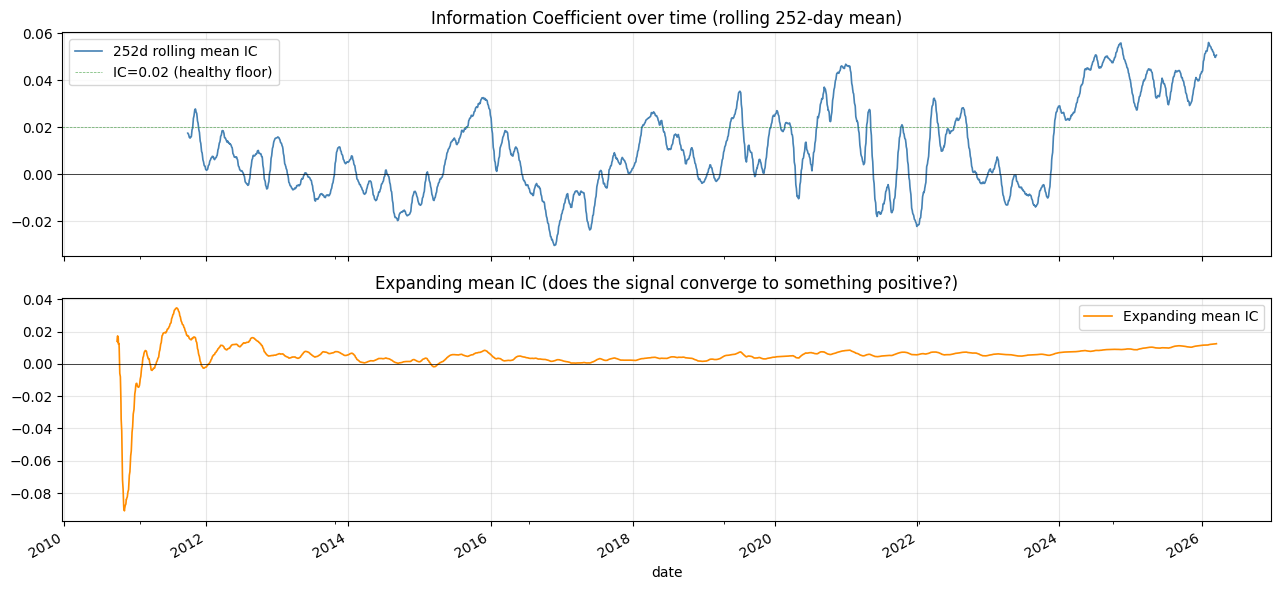

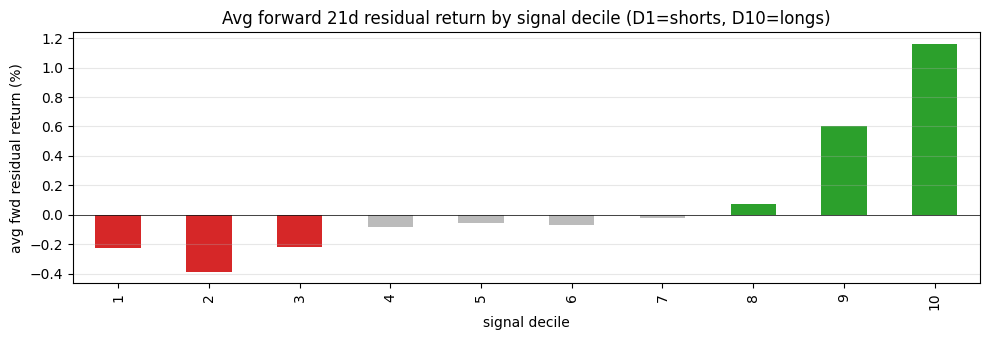


Signal diagnostic complete.


In [34]:
# ==========================================
# 6c. Momentum SIGNAL QUALITY Diagnostics
# ==========================================
# Question: is the 6m sector-residual momentum signal actually predictive of
# forward returns? Or are we losing money because the signal itself is broken?
#
# We measure: (a) Information Coefficient (Spearman rank correlation between
# today's rank and forward residual return), (b) IC over time, (c) IC by sector,
# (d) long-short decile spread, (e) trajectory of biggest losers — were they
# legitimately top-ranked at entry, or signal artifacts?
import matplotlib.pyplot as plt

print("=" * 65)
print("MOMENTUM SIGNAL QUALITY (does the signal actually predict?)")
print("=" * 65)

# --- 1. Compute the same rank used by the strategy (sector-neutral, on residual 6m lagged) ---
# We already have `ranks` from cell 3 — but it was masked by universe. Use it directly.
# Forward residual return horizon = 21 days (matches the skip period of the signal).
FWD_HORIZON = 21
fwd_resid = residual_returns.shift(-FWD_HORIZON).rolling(FWD_HORIZON).sum()
fwd_resid = fwd_resid.shift(-FWD_HORIZON)   # forward-looking: ret over [t+1, t+21]

# Align: ranks and fwd_resid on same dates
common_idx = ranks.dropna(how='all').index.intersection(fwd_resid.dropna(how='all').index)
ranks_c = ranks.loc[common_idx]
fwd_c = fwd_resid.loc[common_idx]

# --- 2. Spearman IC: daily cross-sectional correlation of rank vs forward return ---
print("\n--- Information Coefficient (Spearman) ---")

# Compute per-day IC. Only use days where >= 100 stocks have both rank and fwd return.
ic_series = []
for dt in common_idx:
    r = ranks_c.loc[dt].dropna()
    f = fwd_c.loc[dt].reindex(r.index).dropna()
    if len(f) < 100:
        continue
    common_stocks = r.index.intersection(f.index)
    if len(common_stocks) < 100:
        continue
    ic_series.append((dt, r[common_stocks].rank().corr(f[common_stocks].rank())))

ic_df = pd.DataFrame(ic_series, columns=['date', 'ic']).set_index('date')['ic']
print(f"Sample size: {len(ic_df)} days")
print(f"Mean IC: {ic_df.mean():.4f}   "
      f"Median IC: {ic_df.median():.4f}   "
      f"% days IC > 0: {(ic_df > 0).mean()*100:.1f}%")
print(f"IR (mean IC / std IC, annualized): {ic_df.mean()/ic_df.std()*np.sqrt(252):.3f}")
print(f"  (A healthy signal has mean IC >= 0.02-0.05 and IR >= 1.0)")

# --- 3. IC stability over time ---
print("\n--- IC by calendar year ---")
ic_yearly = ic_df.groupby(ic_df.index.year).agg(['mean', 'std', 'count'])
ic_yearly.columns = ['mean_IC', 'std_IC', 'n_days']
ic_yearly['IR'] = ic_yearly['mean_IC'] / ic_yearly['std_IC'] * np.sqrt(252)
print(ic_yearly.round(4))

# --- 4. IC by sector ---
print("\n--- IC by sector ---")
sector_to_cols = {s: ranks_c.columns[aligned_sectors == s]
                  for s in pd.Series(aligned_sectors).dropna().unique()}

sector_ic_rows = []
for sector, cols in sector_to_cols.items():
    if len(cols) < 30:
        continue
    daily_ics = []
    for dt in common_idx:
        r = ranks_c.loc[dt, cols].dropna()
        f = fwd_c.loc[dt, cols].reindex(r.index).dropna()
        if len(f) < 20:
            continue
        daily_ics.append(r.rank().corr(f.rank()))
    if len(daily_ics) > 100:
        s = pd.Series(daily_ics)
        sector_ic_rows.append({
            'sector': sector, 'n_stocks': len(cols), 'n_days': len(s),
            'mean_IC': s.mean(), 'IR_ann': s.mean()/s.std()*np.sqrt(252)
        })
sector_ic_df = pd.DataFrame(sector_ic_rows).sort_values('mean_IC')
print(sector_ic_df.round(4).to_string(index=False))

# --- 5. Long-Short Decile Spread ---
# Build deciles from the rank, then average forward return per decile
print("\n--- Decile spread (forward 21d residual return by signal decile) ---")
decile_rets = {}
for dec in range(1, 11):
    lo, hi = (dec - 1) / 10, dec / 10
    mask = (ranks_c >= lo) & (ranks_c < hi) if dec < 10 else (ranks_c >= lo)
    rets_in_dec = fwd_c.where(mask)
    decile_rets[dec] = rets_in_dec.stack().mean()
decile_df = pd.Series(decile_rets, name='avg_fwd_21d_resid_ret')
print((decile_df * 100).round(4).to_string())
ls_spread = (decile_df[10] - decile_df[1]) * 100
print(f"\nLong-Short spread (D10 - D1): {ls_spread:.3f}% per 21-day period "
      f"=> annualized ~{ls_spread * (252/21):.2f}%")
print("  (A healthy signal: monotonic increase D1->D10 and positive L-S spread)")

# --- 6. Top losers: were they legitimately top-ranked at entry? ---
print("\n--- Top-5 losers: signal-at-entry forensics ---")
for ticker in ['CHRD', 'LICN', 'MOH', 'RJF', 'BSAC']:
    if ticker not in daily_contrib.columns:
        print(f"  {ticker}: not in portfolio columns"); continue
    pos_series = weights_mom[ticker]
    nonzero_days = pos_series[pos_series != 0]
    if len(nonzero_days) == 0:
        print(f"  {ticker}: never held"); continue

    # Find the first day we held it (entry) and last day (exit)
    entry_dt = nonzero_days.index[0]
    exit_dt = nonzero_days.index[-1]
    entry_sign = np.sign(nonzero_days.iloc[0])

    # Rank at entry (within sector) and trailing 6m residual return at entry
    rank_entry = ranks.loc[entry_dt, ticker] if ticker in ranks.columns else np.nan
    sig_entry = res_ret_6m_lagged.loc[entry_dt, ticker] if entry_dt in res_ret_6m_lagged.index else np.nan

    # Return during holding period
    hold_ret = (1 + returns.loc[entry_dt:exit_dt, ticker]).prod() - 1
    # Position-weighted PnL
    pnl_total = daily_contrib[ticker].sum()
    days_held = (pos_series != 0).sum()
    sector = sector_dict.get(ticker, 'Unknown')

    print(f"  {ticker:6s} ({sector[:24]:24s}) "
          f"side={'L' if entry_sign>0 else 'S'} "
          f"entry={entry_dt.date()} exit={exit_dt.date()} days={days_held:4d} | "
          f"rank@entry={rank_entry:.2f} signal@entry={sig_entry:+.2%} | "
          f"stock_ret_held={hold_ret*100:+.1f}% pnl_contrib={pnl_total*100:+.3f}%")

# --- 7. Visualize IC over time ---
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax = axes[0]
ic_df.rolling(252).mean().plot(ax=ax, color='steelblue', lw=1.2, label='252d rolling mean IC')
ax.axhline(0, color='k', lw=0.5); ax.axhline(0.02, color='g', lw=0.5, ls='--', alpha=0.6, label='IC=0.02 (healthy floor)')
ax.set_title('Information Coefficient over time (rolling 252-day mean)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ic_df.expanding().mean().plot(ax=ax, color='darkorange', lw=1.2, label='Expanding mean IC')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Expanding mean IC (does the signal converge to something positive?)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- 8. Decile-spread bar chart ---
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
colors = ['#d62728' if d <= 3 else '#bbbbbb' if d <= 7 else '#2ca02c' for d in decile_df.index]
(decile_df * 100).plot(kind='bar', ax=ax, color=colors)
ax.set_title(f'Avg forward {FWD_HORIZON}d residual return by signal decile (D1=shorts, D10=longs)')
ax.set_xlabel('signal decile'); ax.set_ylabel('avg fwd residual return (%)')
ax.axhline(0, color='k', lw=0.5); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print("\nSignal diagnostic complete.")

VWAP / MEAN-REVERSION SIGNAL QUALITY

--- IC at lag T+1 (the strongest forward signal) ---
   N days: 4057
   Mean IC: 0.0063   Median: 0.0060   % days > 0: 54.1%   IR_ann: 1.631

--- IC at lag T+2 (the strategy's CURRENT execution lag — for comparison) ---
   Mean IC: 0.0027   IR_ann: 0.709
   --> Moving from T+2 to T+1 captures ~2.4x the signal

--- IC decay curve (single-day forward return at each lag) ---
   (lag 0 omitted — it's contemporaneous, not forward)
     lag     mean_IC      IR_ann     %>0
       1      0.0063       1.631   54.1%
       2      0.0027       0.709   51.0%
       3      0.0009       0.237   50.1%
       5     -0.0012      -0.317   48.1%
      10     -0.0003      -0.073   49.9%

--- IC vs CUMULATIVE forward return (signal(t) -> ret[t+1, t+h]) ---
    horizon     mean_IC      IR_ann
          1      0.0063       1.631
          2      0.0070       1.851
          3      0.0070       1.866
          5      0.0063       1.711
         10      0.0049       1.376


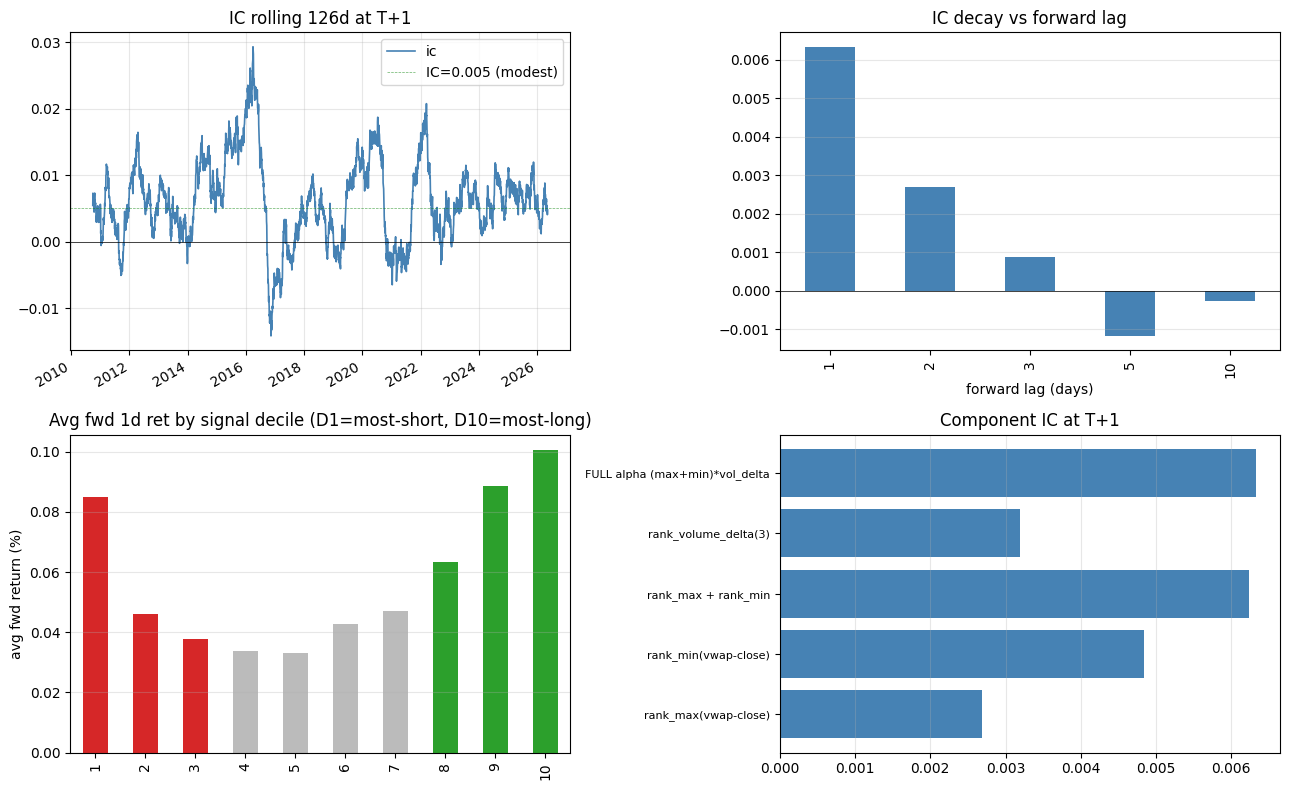


VWAP/MR signal diagnostic complete.


In [40]:
# ==========================================
# 6d. VWAP/MR SIGNAL QUALITY Diagnostics
# ==========================================
# The MR alpha is:
#   alpha = (rank3d_max(vwap-close) + rank3d_min(vwap-close)) * rank(volume.diff(3))
# Then cross-sectionally demeaned -> positive = long, negative = short.
#
# Strategy uses T+2 execution lag.
# Lag 0 IC is the contemporaneous (sanity) check — signal IS today's down-move,
# so lag-0 IC is trivially negative. The real signal lives at lag >= 1.
import matplotlib.pyplot as plt

print("=" * 65)
print("VWAP / MEAN-REVERSION SIGNAL QUALITY")
print("=" * 65)

# --- 1. Rebuild raw signal components (matching cell 2 construction) ---
_vwap = (df_historical['High'] + df_historical['Low'] + df_historical['Close']) / 3.0
_diff_vc = _vwap - df_historical['Close']
_vol_d = df_historical['Volume'].diff(3)

# Dedup all wide frames up front to avoid pandas "duplicate labels" errors
def _dedup(df):
    return df.loc[:, ~df.columns.duplicated()]

_diff_vc = _dedup(_diff_vc)
_vol_d = _dedup(_vol_d)
_univ_dd = _dedup(universe_5m)
_returns_dd = _dedup(returns)

rank_max_only = _diff_vc.rolling(3).max().rank(axis=1, pct=True)
rank_min_only = _diff_vc.rolling(3).min().rank(axis=1, pct=True)
rank_vol_only = _vol_d.rank(axis=1, pct=True)
rank_sum_mm = rank_max_only + rank_min_only

alpha_full = (rank_sum_mm) * rank_vol_only
alpha_full = alpha_full.where(_univ_dd == 1, np.nan)

alpha_signed = alpha_full.sub(alpha_full.mean(axis=1), axis=0)
sub_max     = rank_max_only.where(_univ_dd == 1, np.nan).sub(rank_max_only.mean(axis=1), axis=0)
sub_min     = rank_min_only.where(_univ_dd == 1, np.nan).sub(rank_min_only.mean(axis=1), axis=0)
sub_vol     = rank_vol_only.where(_univ_dd == 1, np.nan).sub(rank_vol_only.mean(axis=1), axis=0)
sub_sum_mm  = rank_sum_mm.where(_univ_dd == 1, np.nan).sub(rank_sum_mm.mean(axis=1), axis=0)


def daily_ic(signal_df, fwd_df, min_stocks=200):
    common_idx = signal_df.dropna(how='all').index.intersection(fwd_df.dropna(how='all').index)
    ics, dates = [], []
    for dt in common_idx:
        s = signal_df.loc[dt].dropna()
        f = fwd_df.loc[dt].reindex(s.index).dropna()
        if len(f) < min_stocks:
            continue
        cs = s.index.intersection(f.index)
        ics.append(s[cs].rank().corr(f[cs].rank())); dates.append(dt)
    return pd.Series(ics, index=pd.DatetimeIndex(dates), name='ic')


# --- 2. Headline IC at T+1 (the most-predictive forward lag — see decay below) ---
print("\n--- IC at lag T+1 (the strongest forward signal) ---")
fwd_t1 = _returns_dd.shift(-1)
ic_t1 = daily_ic(alpha_signed, fwd_t1)
print(f"   N days: {len(ic_t1)}")
print(f"   Mean IC: {ic_t1.mean():.4f}   Median: {ic_t1.median():.4f}   "
      f"% days > 0: {(ic_t1 > 0).mean()*100:.1f}%   "
      f"IR_ann: {ic_t1.mean()/ic_t1.std()*np.sqrt(252):.3f}")

print("\n--- IC at lag T+2 (the strategy's CURRENT execution lag — for comparison) ---")
fwd_t2 = _returns_dd.shift(-2)
ic_t2 = daily_ic(alpha_signed, fwd_t2)
print(f"   Mean IC: {ic_t2.mean():.4f}   IR_ann: {ic_t2.mean()/ic_t2.std()*np.sqrt(252):.3f}")
print(f"   --> Moving from T+2 to T+1 captures ~{ic_t1.mean()/ic_t2.mean():.1f}x the signal")

# --- 3. Decay curve: lag 1..10. Skip lag 0 (it's trivially negative). ---
print("\n--- IC decay curve (single-day forward return at each lag) ---")
print("   (lag 0 omitted — it's contemporaneous, not forward)")
print(f"   {'lag':>5s}  {'mean_IC':>10s}  {'IR_ann':>10s}  {'%>0':>6s}")
lags_to_test = [1, 2, 3, 5, 10]
decay_rows = []
for lag in lags_to_test:
    fwd = _returns_dd.shift(-lag)
    ic = daily_ic(alpha_signed, fwd)
    ir = ic.mean() / ic.std() * np.sqrt(252) if ic.std() > 0 else 0
    decay_rows.append({'lag_days': lag, 'mean_IC': ic.mean(), 'IR_ann': ir, 'pct_pos': (ic>0).mean()*100})
    print(f"   {lag:>5d}  {ic.mean():>10.4f}  {ir:>10.3f}  {(ic>0).mean()*100:>5.1f}%")
decay_df = pd.DataFrame(decay_rows).set_index('lag_days')

# --- 4. Cumulative IC across multi-day horizons ---
print("\n--- IC vs CUMULATIVE forward return (signal(t) -> ret[t+1, t+h]) ---")
print(f"   {'horizon':>8s}  {'mean_IC':>10s}  {'IR_ann':>10s}")
for h in [1, 2, 3, 5, 10]:
    fwd_cum = _returns_dd.rolling(h).sum().shift(-h)
    ic = daily_ic(alpha_signed, fwd_cum)
    ir = ic.mean() / ic.std() * np.sqrt(252) if ic.std() > 0 else 0
    print(f"   {h:>8d}  {ic.mean():>10.4f}  {ir:>10.3f}")

# --- 5. Component decomposition (using T+1 forward) ---
print("\n--- Component decomposition: standalone IC of each sub-signal at lag T+1 ---")
components = {
    'rank_max(vwap-close)':           sub_max,
    'rank_min(vwap-close)':           sub_min,
    'rank_max + rank_min':            sub_sum_mm,
    'rank_volume_delta(3)':           sub_vol,
    'FULL alpha (max+min)*vol_delta': alpha_signed,
}
print(f"   {'component':<40s}  {'mean_IC':>10s}  {'IR_ann':>10s}")
for name, sig in components.items():
    ic = daily_ic(sig, fwd_t1)
    ir = ic.mean() / ic.std() * np.sqrt(252) if ic.std() > 0 else 0
    print(f"   {name:<40s}  {ic.mean():>10.4f}  {ir:>10.3f}")

# --- 6. IC by year at the CORRECT lag (T+1) ---
print("\n--- IC by year (at T+1) ---")
yearly = ic_t1.groupby(ic_t1.index.year).agg(['mean', 'std', 'count'])
yearly.columns = ['mean_IC', 'std_IC', 'n_days']
yearly['IR'] = yearly['mean_IC'] / yearly['std_IC'] * np.sqrt(252)
print(yearly.round(4))

# --- 7. Decile spread at T+1 (uses dedup'd frames) ---
print("\n--- Decile spread (forward 1-day return at lag T+1) ---")
ranks_daily = alpha_signed.rank(axis=1, pct=True)
common = ranks_daily.dropna(how='all').index.intersection(fwd_t1.dropna(how='all').index)
ranks_c = ranks_daily.loc[common]
fwd_c = fwd_t1.loc[common]
# Align columns explicitly to avoid duplicate-axis errors
common_cols = ranks_c.columns.intersection(fwd_c.columns).unique()
ranks_c = ranks_c[common_cols]
fwd_c = fwd_c[common_cols]
dec_rets = {}
for dec in range(1, 11):
    lo, hi = (dec - 1) / 10, dec / 10
    if dec < 10:
        mask = (ranks_c >= lo) & (ranks_c < hi)
    else:
        mask = (ranks_c >= lo)
    masked = fwd_c.where(mask)
    dec_rets[dec] = masked.values[~np.isnan(masked.values)].mean()
dec_s = pd.Series(dec_rets, name='avg_fwd_1d_ret') * 100
print(dec_s.round(4).to_string())
ls_spread = dec_s[10] - dec_s[1]
print(f"   L-S spread (D10 - D1): {ls_spread:.4f}% / day  =>  annualized ~{ls_spread*252:.2f}%")

# --- 8. IC by sector at T+1 ---
print("\n--- IC by sector (at T+1) ---")
sector_ic_rows = []
sectors_aligned = pd.Series(aligned_sectors, index=returns.columns)
sectors_aligned = sectors_aligned[~sectors_aligned.index.duplicated()]
for sector in sectors_aligned.dropna().unique():
    cols = sectors_aligned[sectors_aligned == sector].index
    cols = cols.intersection(alpha_signed.columns).intersection(fwd_t1.columns).unique()
    if len(cols) < 30:
        continue
    ic = daily_ic(alpha_signed[cols], fwd_t1[cols], min_stocks=20)
    if len(ic) < 100:
        continue
    sector_ic_rows.append({
        'sector': sector, 'n_stocks': len(cols), 'n_days': len(ic),
        'mean_IC': ic.mean(), 'IR_ann': ic.mean()/ic.std()*np.sqrt(252)
    })
sector_ic_df = pd.DataFrame(sector_ic_rows).sort_values('mean_IC')
print(sector_ic_df.round(4).to_string(index=False))

# --- 9. Plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ic_t1.rolling(126).mean().plot(ax=ax, color='steelblue', lw=1.2)
ax.axhline(0, color='k', lw=0.5)
ax.axhline(0.005, color='g', lw=0.5, ls='--', alpha=0.6, label='IC=0.005 (modest)')
ax.set_title('IC rolling 126d at T+1'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
decay_df['mean_IC'].plot(ax=ax, kind='bar', color='steelblue')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('IC decay vs forward lag'); ax.set_xlabel('forward lag (days)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
colors = ['#d62728' if d <= 3 else '#bbbbbb' if d <= 7 else '#2ca02c' for d in dec_s.index]
dec_s.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Avg fwd 1d ret by signal decile (D1=most-short, D10=most-long)')
ax.set_ylabel('avg fwd return (%)'); ax.axhline(0, color='k', lw=0.5); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
comp_names = list(components.keys())
comp_ics = [daily_ic(components[n], fwd_t1).mean() for n in comp_names]
ax.barh(range(len(comp_names)), comp_ics, color='steelblue')
ax.set_yticks(range(len(comp_names))); ax.set_yticklabels(comp_names, fontsize=8)
ax.axvline(0, color='k', lw=0.5); ax.set_title('Component IC at T+1')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

print("\nVWAP/MR signal diagnostic complete.")

VWAP/MR SLEEVE PnL FORENSICS

Full sample: ann_ret=5.71%  ann_vol=5.52%  Sharpe=1.035  hit_rate=54.0%  max_dd=-13.9%
Avg daily turnover (sum |Δw|): 73.4%  (lower = better after the smoothing change)

--- Calendar-year PnL ---
      ann_ret  ann_vol  sharpe  n_days
Date                                  
2010    0.048    0.022   2.157     252
2011    0.087    0.029   2.949     252
2012    0.056    0.025   2.234     250
2013    0.073    0.024   3.012     252
2014    0.067    0.030   2.275     252
2015    0.061    0.036   1.686     252
2016    0.015    0.038   0.412     252
2017    0.022    0.023   0.929     251
2018    0.014    0.029   0.504     251
2019    0.082    0.027   3.055     252
2020    0.071    0.162   0.437     253
2021    0.048    0.062   0.780     252
2022    0.069    0.080   0.859     251
2023    0.098    0.034   2.866     250
2024    0.013    0.034   0.365     252
2025    0.091    0.038   2.365     250
2026    0.054    0.062   0.873      93

--- 10 worst single days ---
Dat

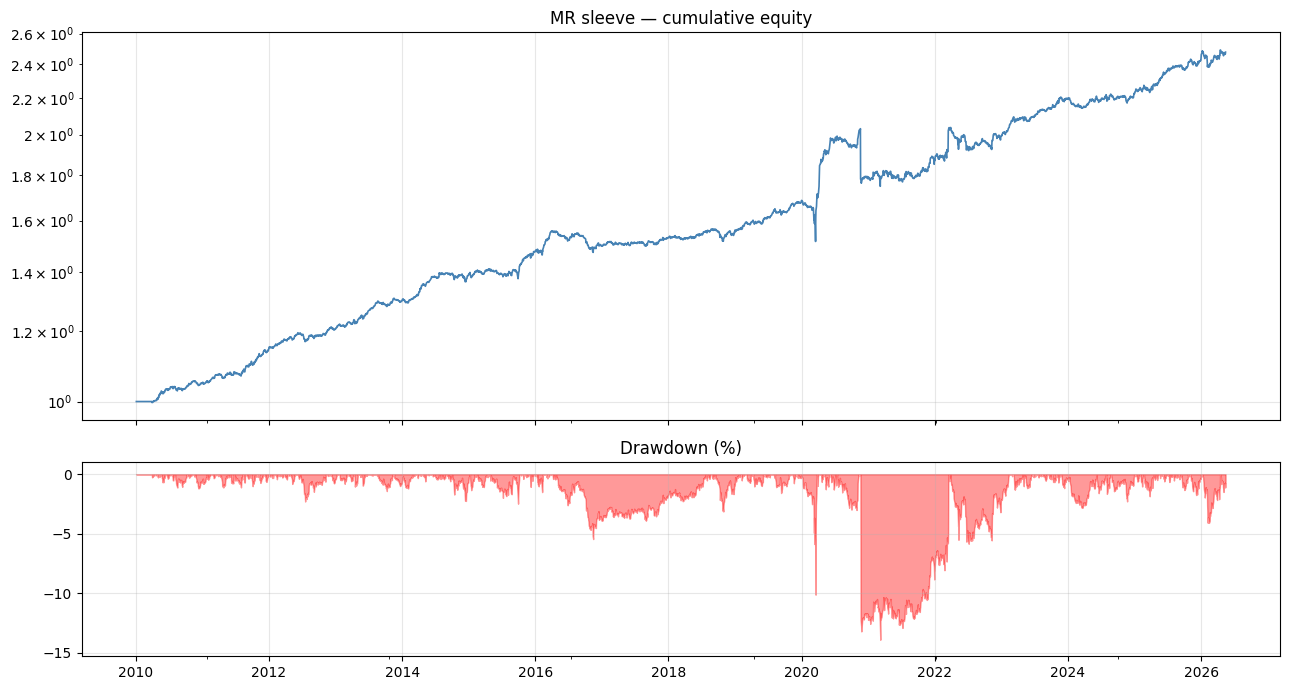

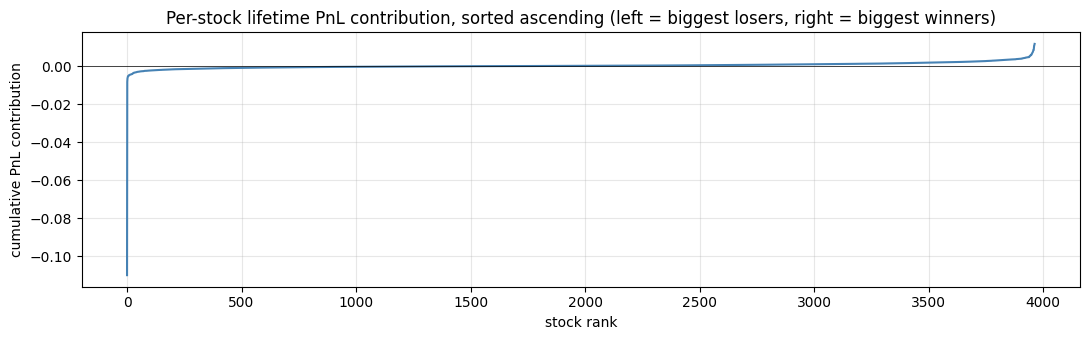

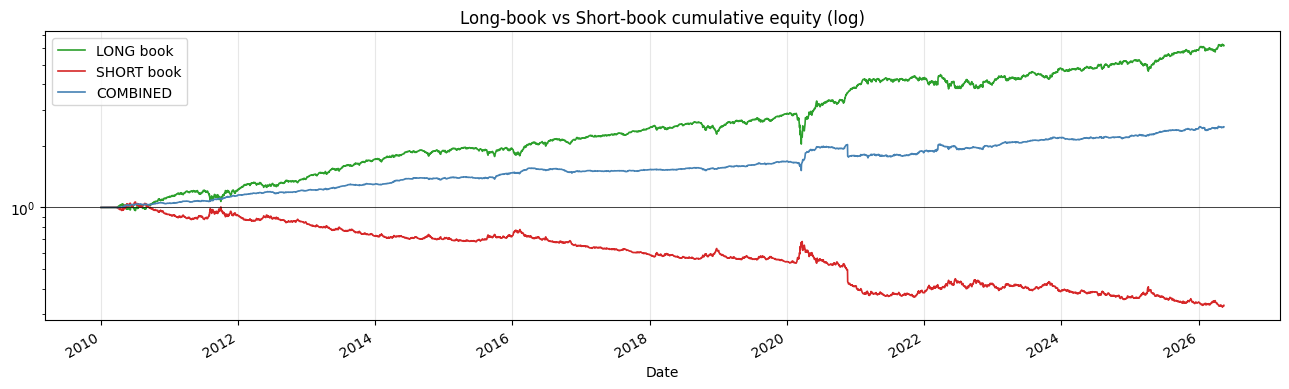


MR forensics complete.


In [29]:
# ==========================================
# 6e. VWAP/MR Sleeve PnL Forensics
# ==========================================
# Same diagnostic structure as cell 6b (momentum forensics), but on the MR weights.
# Looking for: when/where this strategy bleeds, which stocks are toxic, whether
# the losses cluster in identifiable buckets (years, sectors, deciles).
import matplotlib.pyplot as plt

print("=" * 60)
print("VWAP/MR SLEEVE PnL FORENSICS")
print("=" * 60)

# --- 1. Daily PnL series ---
# weights_mr is already shifted (T+1 after the recent fix); pairing with same-day
# returns is causal.
mr_rets = returns.reindex(index=weights_mr.index, columns=weights_mr.columns).fillna(0)
daily_contrib_mr = weights_mr * mr_rets
pnl_daily_mr = daily_contrib_mr.sum(axis=1)
equity_mr = (1 + pnl_daily_mr).cumprod()
dd_mr = equity_mr / equity_mr.cummax() - 1

# --- 2. Headline stats ---
ann_ret = pnl_daily_mr.mean() * 252
ann_vol = pnl_daily_mr.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
hit_rate = (pnl_daily_mr > 0).mean()
turnover_proxy = weights_mr.diff().abs().sum(axis=1).mean()
print(f"\nFull sample: ann_ret={ann_ret*100:.2f}%  ann_vol={ann_vol*100:.2f}%  "
      f"Sharpe={sharpe:.3f}  hit_rate={hit_rate*100:.1f}%  max_dd={dd_mr.min()*100:.1f}%")
print(f"Avg daily turnover (sum |Δw|): {turnover_proxy*100:.1f}%  "
      f"(lower = better after the smoothing change)")

# --- 3. Calendar-year breakdown ---
print("\n--- Calendar-year PnL ---")
yearly = pnl_daily_mr.groupby(pnl_daily_mr.index.year).agg(
    ann_ret=lambda s: s.mean() * 252,
    ann_vol=lambda s: s.std() * np.sqrt(252),
    sharpe=lambda s: (s.mean() / s.std() * np.sqrt(252)) if s.std() > 0 else 0,
    n_days='count',
)
print(yearly.round(3))

# --- 4. Worst single days and worst weeks ---
print("\n--- 10 worst single days ---")
print((pnl_daily_mr.nsmallest(10) * 100).round(3).rename('pct').to_string())

print("\n--- 10 worst calendar weeks ---")
weekly_pnl = pnl_daily_mr.resample('W-FRI').sum()
print((weekly_pnl.nsmallest(10) * 100).round(3).rename('pct').to_string())

# --- 5. Drawdown periods ---
print("\n--- Top 5 drawdown episodes (peak -> trough) ---")
in_dd = dd_mr < 0
dd_groups = (in_dd != in_dd.shift()).cumsum()
episodes = []
for gid, grp in dd_mr.groupby(dd_groups):
    if grp.iloc[0] >= 0:
        continue
    episodes.append({
        'start': grp.index[0].date(),
        'trough_date': grp.idxmin().date(),
        'end': grp.index[-1].date(),
        'depth_pct': grp.min() * 100,
        'days': len(grp),
    })
episodes_df = pd.DataFrame(episodes).sort_values('depth_pct').head(5)
print(episodes_df.to_string(index=False))

# --- 6. Per-stock contribution (lifetime) ---
stock_total = daily_contrib_mr.sum(axis=0)
stock_total_nz = stock_total[stock_total != 0]
print(f"\n--- Stock-level contribution (across {len(stock_total_nz)} ever-traded names) ---")
print("Top 10 LOSERS (lifetime PnL):")
print((stock_total_nz.nsmallest(10) * 100).round(3).rename('pnl_%').to_string())
print("\nTop 10 WINNERS (lifetime PnL):")
print((stock_total_nz.nlargest(10) * 100).round(3).rename('pnl_%').to_string())

# --- 7. Concentration: bottom-decile names vs the rest ---
n_names = len(stock_total_nz)
sorted_pnl = stock_total_nz.sort_values()
bottom_decile = sorted_pnl.iloc[:max(1, n_names // 10)]
total_pnl_sum = stock_total_nz.sum()
if abs(total_pnl_sum) > 1e-9:
    print(f"\nBottom-decile names ({len(bottom_decile)}) drove "
          f"{bottom_decile.sum() / total_pnl_sum * 100:.1f}% of total PnL "
          f"(negative % = sinking strategy more than their share)")

# --- 8. Long-side vs short-side attribution (key for MR — diagnostic showed shorts are wrong-way) ---
print("\n--- Long-side vs Short-side attribution ---")
long_pnl = (weights_mr.where(weights_mr > 0, 0) * mr_rets).sum(axis=1)
short_pnl = (weights_mr.where(weights_mr < 0, 0) * mr_rets).sum(axis=1)
print(f"Long  book : ann_ret={long_pnl.mean()*252*100:+.3f}%  "
      f"vol={long_pnl.std()*np.sqrt(252)*100:.3f}%  "
      f"Sharpe={long_pnl.mean()/long_pnl.std()*np.sqrt(252):+.3f}")
print(f"Short book : ann_ret={short_pnl.mean()*252*100:+.3f}%  "
      f"vol={short_pnl.std()*np.sqrt(252)*100:.3f}%  "
      f"Sharpe={short_pnl.mean()/short_pnl.std()*np.sqrt(252):+.3f}")
print(f"Combined   : ann_ret={pnl_daily_mr.mean()*252*100:+.3f}%  "
      f"Sharpe={sharpe:+.3f}")
print("  (If short Sharpe is materially negative, the L-S structure is dragging — "
      "confirms diagnostic finding that bottom-decile shorts have wrong-way edge.)")

# --- 9. Sector-level PnL attribution ---
print("\n--- Sector-level lifetime PnL contribution ---")
sectors_for_pnl = pd.Series(aligned_sectors, index=returns.columns)
sectors_for_pnl = sectors_for_pnl[~sectors_for_pnl.index.duplicated()]
sector_rows = []
for sec in sectors_for_pnl.dropna().unique():
    cols = sectors_for_pnl[sectors_for_pnl == sec].index.intersection(stock_total.index).unique()
    if len(cols) == 0:
        continue
    pnl_sec = stock_total[cols].sum()
    sector_rows.append({'sector': sec, 'n_stocks': len(cols), 'lifetime_pnl_%': pnl_sec * 100})
sec_pnl_df = pd.DataFrame(sector_rows).sort_values('lifetime_pnl_%')
print(sec_pnl_df.round(3).to_string(index=False))

# --- 10. Plots ---
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
ax = axes[0]
equity_mr.plot(ax=ax, color='steelblue', lw=1.2)
ax.set_title('MR sleeve — cumulative equity')
ax.set_yscale('log'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.fill_between(dd_mr.index, dd_mr.values * 100, 0, color='red', alpha=0.4)
ax.set_title('Drawdown (%)')
ax.set_ylim(min(dd_mr.min() * 100 * 1.1, -1), 1); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Per-stock PnL distribution
fig, ax = plt.subplots(1, 1, figsize=(11, 3.5))
stock_total_nz.sort_values().reset_index(drop=True).plot(ax=ax, color='steelblue')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Per-stock lifetime PnL contribution, sorted ascending '
             '(left = biggest losers, right = biggest winners)')
ax.set_xlabel('stock rank'); ax.set_ylabel('cumulative PnL contribution')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Long vs short cumulative attribution
fig, ax = plt.subplots(1, 1, figsize=(13, 4))
(1 + long_pnl).cumprod().plot(ax=ax, color='#2ca02c', lw=1.2, label='LONG book')
(1 + short_pnl).cumprod().plot(ax=ax, color='#d62728', lw=1.2, label='SHORT book')
(1 + pnl_daily_mr).cumprod().plot(ax=ax, color='steelblue', lw=1.2, label='COMBINED')
ax.set_yscale('log'); ax.axhline(1, color='k', lw=0.5)
ax.set_title('Long-book vs Short-book cumulative equity (log)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nMR forensics complete.")

In [ ]:
# ==========================================
# 6f. MR Signal — PROPER L/S Cross-Sectional Analysis (dollar-neutral)
# ==========================================
# A dollar-neutral L/S doesn't capture market drift — it captures cross-sectional
# dispersion around the daily mean. So we demean fwd returns by the daily XS mean
# and evaluate decile spread + enumerate L/S bucket designs.
import matplotlib.pyplot as plt

print("=" * 65)
print("MR SIGNAL — PROPER CROSS-SECTIONAL L/S ANALYSIS")
print("=" * 65)

# --- Rebuild signal and fwd return at T+1 (best lag from cell 6d) ---
_vwap = (df_historical['High'] + df_historical['Low'] + df_historical['Close']) / 3.0
_diff_vc = _vwap - df_historical['Close']
_vol_d = df_historical['Volume'].diff(3)

def _dd(df): return df.loc[:, ~df.columns.duplicated()]
_diff_vc = _dd(_diff_vc); _vol_d = _dd(_vol_d)
_univ = _dd(universe_5m)

# CLEAN returns: pct_change on near-zero prices produces inf which poisons row means.
# Replace +/-inf with NaN, then clip to a sane daily range (-50% to +200%) since
# anything beyond is almost certainly a price-data artifact (e.g. ticker re-issue,
# split not applied). This stops one bad row from making every decile -inf.
_rets = _dd(returns).replace([np.inf, -np.inf], np.nan).clip(lower=-0.5, upper=2.0)

rank_max = _diff_vc.rolling(3).max().rank(axis=1, pct=True)
rank_min = _diff_vc.rolling(3).min().rank(axis=1, pct=True)
rank_vol = _vol_d.rank(axis=1, pct=True)
alpha_raw = ((rank_max + rank_min) * rank_vol).where(_univ == 1, np.nan)
alpha_signed = alpha_raw.sub(alpha_raw.mean(axis=1), axis=0)

fwd = _rets.shift(-1)
fwd_xs = fwd.sub(fwd.mean(axis=1, skipna=True), axis=0)

# --- 1. Decile spread: raw vs demeaned ---
print("\n--- Decile spread: raw vs cross-sectionally demeaned ---")
print("  D# = decile of signed alpha (D1 = lowest signal = current SHORT bucket)")

def decile_table(signal, fwd_, name):
    ranks_d = signal.rank(axis=1, pct=True)
    common = ranks_d.dropna(how='all').index.intersection(fwd_.dropna(how='all').index)
    r = ranks_d.loc[common]; f = fwd_.loc[common]
    cols = r.columns.intersection(f.columns).unique()
    r = r[cols]; f = f[cols]
    means = {}
    for d in range(1, 11):
        lo, hi = (d-1)/10, d/10
        m = (r >= lo) & (r < hi) if d < 10 else (r >= lo)
        means[d] = np.nanmean(f.where(m).values)
    return pd.Series(means, name=name) * 100

raw_table = decile_table(alpha_signed, fwd, 'fwd_raw_%')
dem_table = decile_table(alpha_signed, fwd_xs, 'fwd_demeaned_%')
comp = pd.concat([raw_table, dem_table], axis=1).round(4)
comp['mkt_drift_%'] = (raw_table - dem_table).round(4)
print(comp.to_string())

ls_raw = raw_table[10] - raw_table[1]
ls_dem = dem_table[10] - dem_table[1]
mkt = (raw_table - dem_table).mean()
print(f"\n  L-S spread (D10 - D1) on RAW:      {ls_raw:.4f}% / day")
print(f"  L-S spread (D10 - D1) on DEMEANED: {ls_dem:.4f}% / day "
      f"<- what dollar-neutral L/S actually captures")
print(f"  Daily market drift: ~{mkt:.4f}% / day = {mkt*252:.2f}% / year")

# --- 2. Deciles ranked by demeaned return ---
print("\n--- Deciles ranked by DEMEANED forward return (ascending) ---")
print(dem_table.sort_values().round(4).rename('demeaned_fwd_%').to_string())
print("\n  Negative = underperforms daily avg = good short candidate.")

# --- 3. Enumerate L/S bucket designs ---
print("\n--- L/S design enumeration ---")
all_buckets = [(lo, hi) for lo in range(1, 11) for hi in range(lo, 11)]
bucket_avg = {(lo, hi): dem_table.loc[lo:hi].mean() for lo, hi in all_buckets}

rows = []
for L_lo, L_hi in all_buckets:
    for S_lo, S_hi in all_buckets:
        if not (L_lo > S_hi):
            continue
        alpha_day = 0.5 * (bucket_avg[(L_lo, L_hi)] - bucket_avg[(S_lo, S_hi)])
        rows.append({
            'long_buckets':  f"D{L_lo}..D{L_hi}",
            'short_buckets': f"D{S_lo}..D{S_hi}",
            'n_long_dec':    L_hi - L_lo + 1,
            'n_short_dec':   S_hi - S_lo + 1,
            'avg_long_%':    round(bucket_avg[(L_lo, L_hi)], 4),
            'avg_short_%':   round(bucket_avg[(S_lo, S_hi)], 4),
            'alpha_ann_%':   round(alpha_day * 252, 2),
        })
designs = pd.DataFrame(rows).sort_values('alpha_ann_%', ascending=False)
print("\nTop 15 designs by expected annualised alpha (XS only):")
print(designs.head(15).to_string(index=False))

cur = designs[(designs['long_buckets'] == 'D10..D10') & (designs['short_buckets'] == 'D1..D1')]
print("\nCurrent strategy (long D10 / short D1):")
print(cur.to_string(index=False))

# --- 4. Vol-effect check ---
print("\n--- 60d realised vol by signal decile ---")
stock_vol_60d = _rets.rolling(60, min_periods=30).std()
ranks_d = alpha_signed.rank(axis=1, pct=True)
common = ranks_d.dropna(how='all').index.intersection(stock_vol_60d.dropna(how='all').index)
r = ranks_d.loc[common]; v = stock_vol_60d.loc[common]
cols = r.columns.intersection(v.columns).unique()
r = r[cols]; v = v[cols]
vol_by_dec = {}
for d in range(1, 11):
    lo, hi = (d-1)/10, d/10
    m = (r >= lo) & (r < hi) if d < 10 else (r >= lo)
    vol_by_dec[d] = np.nanmean(v.where(m).values)
vol_s = pd.Series(vol_by_dec, name='avg_60d_vol_%') * 100
print(vol_s.round(3).to_string())

# --- 5. Plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
x = np.arange(1, 11)
ax.bar(x - 0.2, comp['fwd_raw_%'], width=0.4, color='steelblue', label='Raw')
ax.bar(x + 0.2, comp['fwd_demeaned_%'], width=0.4, color='darkorange', label='Demeaned (XS)')
ax.axhline(0, color='k', lw=0.5); ax.legend()
ax.set_xticks(x); ax.set_title('Raw vs demeaned fwd returns by decile')
ax.set_xlabel('signal decile'); ax.set_ylabel('avg fwd return (%)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
colors = ['#d62728' if v < 0 else '#2ca02c' for v in dem_table.values]
ax.bar(x, dem_table.values, color=colors)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_title('DEMEANED fwd return by decile (red = XS losers)')
ax.set_xlabel('signal decile'); ax.set_ylabel('demeaned fwd return (%)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.bar(x, vol_s.values, color='steelblue')
ax.set_xticks(x); ax.set_title('60d realised vol by signal decile')
ax.set_xlabel('signal decile'); ax.set_ylabel('avg 60d vol (%)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
top10 = designs.head(10).iloc[::-1]
labels = top10['long_buckets'] + '  /  ' + top10['short_buckets']
ax.barh(range(len(top10)), top10['alpha_ann_%'], color='steelblue')
ax.set_yticks(range(len(top10))); ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('Top 10 L/S designs by expected ann. alpha')
ax.set_xlabel('annualised alpha (%)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout(); plt.show()
print("\nProper L/S analysis complete.")
